In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

In [2]:
DATA_DIR = 'data'

In [3]:
users = pd.read_csv('{}/users.csv.gz'.format(DATA_DIR))
events = pd.read_csv('{}/events.csv.gz'.format(DATA_DIR))
transactions = pd.read_csv('{}/transactions.csv.gz'.format(DATA_DIR))

## Preprocessing the data

### Clean user profile fields

In [4]:
# RAW
users.head()

,user_id,gender,canton,class_level,study,class_id
0,387604,NaN,NaN,NaN,False,NaN
1,387605,NaN,NaN,NaN,False,NaN
2,387608,NaN,NaN,NaN,True,9Q2M7
3,387613,NaN,NaN,NaN,False,NaN
4,387615,MALE,SG,Gymnasium - 3. Jahr,False,NaN


In [5]:
users_clean = users.copy()  # Work on a copy to keep raw data unchanged

# Normalize gender values and fill missing entries
users_clean['gender'] = (
    users_clean['gender']
    .replace({'*': np.nan, 'STAR': 'Other'})
    .fillna('Unknown')
)

# Fill missing categorical profile fields
users_clean['canton'] = users_clean['canton'].fillna('Unknown')
users_clean['class_level'] = users_clean['class_level'].fillna('Unknown')
users_clean['class_id'] = users_clean['class_id'].fillna('Unknown')

# Ensure study is boolean
users_clean['study'] = users_clean['study'].replace({'True': True, 'False': False}).fillna(False).astype(bool)

users_clean.head()

,user_id,gender,canton,class_level,study,class_id
0,387604,Unknown,Unknown,Unknown,False,Unknown
1,387605,Unknown,Unknown,Unknown,False,Unknown
2,387608,Unknown,Unknown,Unknown,True,9Q2M7
3,387613,Unknown,Unknown,Unknown,False,Unknown
4,387615,MALE,SG,Gymnasium - 3. Jahr,False,Unknown


In [6]:
del users
gc.collect()

0

### Clean event timestamps and calendar features

In [7]:
# RAW
events.head()

,event_id,user_id,event_date,category,action,event_type,transaction_token,tracking_data,session_id,topic_id,session_closed,session_type,session_accepted
0,62,393211,2021-05-21 07:56:54.885,TASK,VIEW_QUESTION,VIEW,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN
1,63,393211,2021-05-21 07:58:18.912,TASK,SUBMIT_ANSWER,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN
2,64,393211,2021-05-21 07:58:27.207,TASK,NEXT,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN
3,65,393211,2021-05-21 07:58:27.589,TASK,VIEW_QUESTION,VIEW,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN
4,66,393211,2021-05-21 08:03:42.588,TASK,SUBMIT_ANSWER,CLICK,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
events_clean = events.copy()  # Keep raw events unchanged

events_clean['event_date'] = pd.to_datetime(events_clean['event_date'], errors='coerce')
events_clean = events_clean.dropna(subset=['user_id', 'event_date'])  # Remove unusable rows

# Time-based features for analysis/aggregation
events_clean['date'] = events_clean['event_date'].dt.date
events_clean['year'] = events_clean['event_date'].dt.year
events_clean['month'] = events_clean['event_date'].dt.month
events_clean['dayofweek'] = events_clean['event_date'].dt.dayofweek
events_clean['hour'] = events_clean['event_date'].dt.hour
events_clean['week'] = events_clean['event_date'].dt.to_period('W').astype(str)

events_clean.head()

,event_id,user_id,event_date,category,action,event_type,transaction_token,tracking_data,session_id,topic_id,session_closed,session_type,session_accepted,date,year,month,dayofweek,hour,week
0,62,393211,2021-05-21 07:56:54.885,TASK,VIEW_QUESTION,VIEW,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
1,63,393211,2021-05-21 07:58:18.912,TASK,SUBMIT_ANSWER,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
2,64,393211,2021-05-21 07:58:27.207,TASK,NEXT,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
3,65,393211,2021-05-21 07:58:27.589,TASK,VIEW_QUESTION,VIEW,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
4,66,393211,2021-05-21 08:03:42.588,TASK,SUBMIT_ANSWER,CLICK,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23


In [9]:
del events
gc.collect()

0

### Clean transaction timestamps and scoring features

In [10]:
# RAW
transactions.head()

,transaction_id,transaction_token,user_id,document_id,document_version,evaluation,input,start_time,commit_time,user_agent,...,type,session_id,topic_id,session_closed,session_type,session_accepted,challenge,challenge_id,challenge_order,challenge_name
0,688413,88fdcaad-f73b-46a2-b561-d262f2441442,393211,awd0i1DlVtg6kuMZSkpmHa,75002,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 07:58:27.312000000,2021-05-21 08:03:43.020000000,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,MULTI_COLOR_HIGHLIGHT,NaN,NaN,NaN,NaN,NaN,True,1083.0,2.0,G3h – Training Rhetorik
1,688414,a75eb7b4-b2c2-47d4-9200-27980c175037,393211,arhWF3BT53V9W8cGOaZVPX,75012,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 08:04:05.067000000,2021-05-21 08:07:21.288999936,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,MULTI_COLOR_HIGHLIGHT,NaN,NaN,NaN,NaN,NaN,True,1083.0,3.0,G3h – Training Rhetorik
2,688415,61eb829d-bdda-4107-86af-ad9a14a7bdc9,393211,9wk5dtV2mF59odW0wCEYYc,75003,PARTIAL,"{""type"": ""CLOZE_TEXT"", ""clozeInputs"": [""Person...",2021-05-21 08:07:37.048000000,2021-05-21 08:13:30.953999872,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,CLOZE_TEXT,NaN,NaN,NaN,NaN,NaN,True,1083.0,4.0,G3h – Training Rhetorik
3,688416,30ff0d8a-865d-460b-9177-b698a52b0d5c,393211,afilxZ8LycP5LReULeKngW,75009,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Ich gehe i...",2021-05-21 08:13:38.943000000,2021-05-21 08:22:13.975000064,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,DND_PAIRS,NaN,NaN,NaN,NaN,NaN,True,1083.0,5.0,G3h – Training Rhetorik
4,688417,0adedf3b-ba35-4497-8c6b-b5c2f6fcbbf3,393211,76m6v05NCeX8x2Wr5tKRE3,75007,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Kleiner Ma...",2021-05-21 08:22:19.391000000,2021-05-21 08:22:55.366000128,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,DND_PAIRS,NaN,NaN,NaN,NaN,NaN,True,1083.0,6.0,G3h – Training Rhetorik


In [11]:
transactions_clean = transactions.copy()  # keep raw transactions unchanged

# parse timestamps and drop rows missing required keys/time
transactions_clean['start_time'] = pd.to_datetime(transactions_clean['start_time'], errors='coerce')
transactions_clean['commit_time'] = pd.to_datetime(transactions_clean['commit_time'], errors='coerce')
transactions_clean = transactions_clean.dropna(subset=['user_id', 'start_time'])

# derive time features from start_time
transactions_clean['date'] = transactions_clean['start_time'].dt.date
transactions_clean['year'] = transactions_clean['start_time'].dt.year
transactions_clean['month'] = transactions_clean['start_time'].dt.month
transactions_clean['dayofweek'] = transactions_clean['start_time'].dt.dayofweek
transactions_clean['hour'] = transactions_clean['start_time'].dt.hour
transactions_clean['week'] = transactions_clean['start_time'].dt.to_period('W').astype(str)

transactions_clean.head()

,transaction_id,transaction_token,user_id,document_id,document_version,evaluation,input,start_time,commit_time,user_agent,...,challenge,challenge_id,challenge_order,challenge_name,date,year,month,dayofweek,hour,week
0,688413,88fdcaad-f73b-46a2-b561-d262f2441442,393211,awd0i1DlVtg6kuMZSkpmHa,75002,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 07:58:27.312,2021-05-21 08:03:43.020000000,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,2.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
1,688414,a75eb7b4-b2c2-47d4-9200-27980c175037,393211,arhWF3BT53V9W8cGOaZVPX,75012,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 08:04:05.067,2021-05-21 08:07:21.288999936,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,3.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23
2,688415,61eb829d-bdda-4107-86af-ad9a14a7bdc9,393211,9wk5dtV2mF59odW0wCEYYc,75003,PARTIAL,"{""type"": ""CLOZE_TEXT"", ""clozeInputs"": [""Person...",2021-05-21 08:07:37.048,2021-05-21 08:13:30.953999872,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,4.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23
3,688416,30ff0d8a-865d-460b-9177-b698a52b0d5c,393211,afilxZ8LycP5LReULeKngW,75009,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Ich gehe i...",2021-05-21 08:13:38.943,2021-05-21 08:22:13.975000064,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,5.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23
4,688417,0adedf3b-ba35-4497-8c6b-b5c2f6fcbbf3,393211,76m6v05NCeX8x2Wr5tKRE3,75007,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Kleiner Ma...",2021-05-21 08:22:19.391,2021-05-21 08:22:55.366000128,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,6.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23


In [12]:
del transactions
gc.collect()

0

In [13]:
# Clean evaluation labels and derive outcome flags
transactions_clean['evaluation'] = transactions_clean['evaluation'].fillna('UNKNOWN')

# Soft correctness score
transactions_clean['evaluation_score'] = transactions_clean['evaluation'].map({
    'CORRECT': 1.0,
    'PARTIAL': 0.5,
    'WRONG': 0.0,
    'UNKNOWN': 0.0
}).fillna(0.0)

transactions_clean['is_correct'] = (transactions_clean['evaluation'] == 'CORRECT').astype(int)
transactions_clean['is_partial'] = (transactions_clean['evaluation'] == 'PARTIAL').astype(int)
transactions_clean['is_unknown_eval'] = (transactions_clean['evaluation'] == 'UNKNOWN').astype(int)

# Compute response time in seconds
transactions_clean['response_time_sec'] = (
    transactions_clean['commit_time'] - transactions_clean['start_time']
).dt.total_seconds()

# Remove implausible response times (discard values > 1 hour but could be adjusted)
transactions_clean.loc[
    (transactions_clean['response_time_sec'] < 0) | (transactions_clean['response_time_sec'] > 3600),
    'response_time_sec'
] = np.nan

transactions_clean.head()

,transaction_id,transaction_token,user_id,document_id,document_version,evaluation,input,start_time,commit_time,user_agent,...,year,month,dayofweek,hour,week,evaluation_score,is_correct,is_partial,is_unknown_eval,response_time_sec
0,688413,88fdcaad-f73b-46a2-b561-d262f2441442,393211,awd0i1DlVtg6kuMZSkpmHa,75002,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 07:58:27.312,2021-05-21 08:03:43.020000000,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,7,2021-05-17/2021-05-23,0.5,0,1,0,315.708
1,688414,a75eb7b4-b2c2-47d4-9200-27980c175037,393211,arhWF3BT53V9W8cGOaZVPX,75012,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 08:04:05.067,2021-05-21 08:07:21.288999936,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,0.5,0,1,0,196.222
2,688415,61eb829d-bdda-4107-86af-ad9a14a7bdc9,393211,9wk5dtV2mF59odW0wCEYYc,75003,PARTIAL,"{""type"": ""CLOZE_TEXT"", ""clozeInputs"": [""Person...",2021-05-21 08:07:37.048,2021-05-21 08:13:30.953999872,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,0.5,0,1,0,353.906
3,688416,30ff0d8a-865d-460b-9177-b698a52b0d5c,393211,afilxZ8LycP5LReULeKngW,75009,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Ich gehe i...",2021-05-21 08:13:38.943,2021-05-21 08:22:13.975000064,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,1.0,1,0,0,515.032
4,688417,0adedf3b-ba35-4497-8c6b-b5c2f6fcbbf3,393211,76m6v05NCeX8x2Wr5tKRE3,75007,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Kleiner Ma...",2021-05-21 08:22:19.391,2021-05-21 08:22:55.366000128,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,1.0,1,0,0,35.975


### Build a user-relative timeline

In [14]:
# Define week 0 as each user's first recorded transaction
first_activity = (
    transactions_clean.groupby('user_id', as_index=False)['start_time']
    .min()
    .rename(columns={'start_time': 'first_activity_time'})
)

events_clean = events_clean.merge(first_activity, on='user_id', how='left')
transactions_clean = transactions_clean.merge(first_activity, on='user_id', how='left')

events_clean['relative_week'] = (
    (events_clean['event_date'] - events_clean['first_activity_time']).dt.days // 7
).astype('Int64')
transactions_clean['relative_week'] = (
    (transactions_clean['start_time'] - transactions_clean['first_activity_time']).dt.days // 7
).astype('Int64')

events_clean.head()



,event_id,user_id,event_date,category,action,event_type,transaction_token,tracking_data,session_id,topic_id,...,session_type,session_accepted,date,year,month,dayofweek,hour,week,first_activity_time,relative_week
0,62,393211,2021-05-21 07:56:54.885,TASK,VIEW_QUESTION,VIEW,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,-1
1,63,393211,2021-05-21 07:58:18.912,TASK,SUBMIT_ANSWER,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,-1
2,64,393211,2021-05-21 07:58:27.207,TASK,NEXT,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,-1
3,65,393211,2021-05-21 07:58:27.589,TASK,VIEW_QUESTION,VIEW,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,0
4,66,393211,2021-05-21 08:03:42.588,TASK,SUBMIT_ANSWER,CLICK,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,0


Negative relative_week values occur when a user has events recorded before their first transaction, since week 0 is defined from the first transaction timestamp.


*events is broader than transactions, so it can contain earlier activity like page views or navigation*

## Generic Features

In [15]:
# Aggregate per-user event activity features
event_user_features = events_clean.groupby('user_id').agg(
    n_events=('event_id', 'count'),
    n_active_days=('date', 'nunique'),
    n_active_weeks=('week', 'nunique'),
    first_event=('event_date', 'min'),
    last_event=('event_date', 'max'),
    mean_event_hour=('hour', 'mean')
).reset_index()

event_user_features.head()

,user_id,n_events,n_active_days,n_active_weeks,first_event,last_event,mean_event_hour
0,387604,5087,100,54,2021-05-22 05:12:11.416,2023-01-25 20:53:32.597,10.359741
1,387605,3604,54,33,2021-05-27 06:46:53.301,2022-11-01 08:22:13.245,10.089345
2,387608,2359,87,47,2021-09-05 08:29:42.198,2023-01-27 08:50:57.481,11.119118
3,387613,213,5,4,2021-07-28 07:55:26.135,2022-11-13 10:44:02.194,9.516432
4,387615,535,12,9,2021-08-28 13:14:30.684,2023-02-02 14:07:09.779,10.542056


In [16]:
# Count how many times each action appears per user
action_counts = pd.crosstab(events_clean['user_id'], events_clean['action'])

# Prefix action columns for clarity (e.g., action_login, action_next, ...)
action_counts.columns = [f'action_{c.lower()}' for c in action_counts.columns]

# Bring user_id back as a regular column for merging
action_counts = action_counts.reset_index()

action_counts.head()

,user_id,action_accept_progress,action_close,action_close_feedback,action_go_to_bug_report,action_go_to_comments,action_go_to_session,action_go_to_theory,action_login,action_logout,...,action_skip,action_submit_answer,action_submit_search,action_survey_banner,action_view_question,action_view_session_end,action_window_close,action_window_open,action_window_visible_false,action_window_visible_true
0,387604,8,35,34,5,4,0,677,38,1,...,83,361,16,93,355,51,151,160,305,211
1,387605,2,84,72,14,2,1,35,47,12,...,48,239,1,100,137,45,140,197,412,263
2,387608,5,39,10,7,1,0,58,47,2,...,19,117,21,32,170,33,96,103,243,161
3,387613,0,2,0,0,0,0,7,5,0,...,5,4,0,0,0,1,4,2,56,50
4,387615,0,4,1,1,1,0,18,16,4,...,0,15,17,0,17,2,27,26,65,34


In [17]:
# Count event types per user
event_type_counts = pd.crosstab(events_clean['user_id'], events_clean['event_type'])
event_type_counts.columns = [f'event_type_{c.lower()}' for c in event_type_counts.columns]
event_type_counts = event_type_counts.reset_index()

event_type_counts.head()

,user_id,event_type_click,event_type_view
0,387604,1408,3679
1,387605,959,2645
2,387608,516,1843
3,387613,38,175
4,387615,109,426


In [18]:
# Per-user transaction behavior summary
transaction_user_features = transactions_clean.groupby('user_id').agg(
    n_transactions=('transaction_id', 'count'),      # total attempts
    n_transaction_weeks=('week', 'nunique'),         # weeks with at least one transaction
    n_documents=('document_id', 'nunique'),          # unique documents worked on
    n_topics=('topic_id', 'nunique'),                # unique topics covered
    correct_rate=('is_correct', 'mean'),
    partial_rate=('is_partial', 'mean'),
    avg_response_time=('response_time_sec', 'mean'),
    median_response_time=('response_time_sec', 'median'),
    n_challenges=('challenge_id', 'nunique')         # distinct challenge sets
).reset_index()

transaction_user_features.head()

,user_id,n_transactions,n_transaction_weeks,n_documents,n_topics,correct_rate,partial_rate,avg_response_time,median_response_time,n_challenges
0,387604,846,42,337,13,0.208038,0.174941,53.863150,18.2290,3
1,387605,482,28,255,25,0.207469,0.151452,31.534444,20.4440,6
2,387608,361,38,245,12,0.257618,0.022161,54.978811,20.6645,6
3,387613,12,3,12,3,0.333333,0.000000,16.232111,5.6790,0
4,387615,40,5,20,1,0.250000,0.075000,46.730929,26.2795,1


In [19]:
user_features = users_clean.merge(event_user_features, on='user_id', how='left')
user_features = user_features.merge(action_counts, on='user_id', how='left')
user_features = user_features.merge(event_type_counts, on='user_id', how='left')
user_features = user_features.merge(transaction_user_features, on='user_id', how='left')

# Fill count-like features with 0
count_cols = [
    col for col in user_features.columns
    if col.startswith('n_') or col.startswith('action_') or col.startswith('event_type_')
]
user_features[count_cols] = user_features[count_cols].fillna(0)

# Fill main rates with 0 when user has no transactions
rate_cols = ['correct_rate', 'partial_rate']
user_features[rate_cols] = user_features[rate_cols].fillna(0)

# Indicators for missing activity / transactions
user_features['has_events'] = user_features['first_event'].notna().astype(int)
user_features['has_transactions'] = user_features['n_transactions'].gt(0).astype(int)

# Activity span
user_features['activity_span_days'] = (
    user_features['last_event'] - user_features['first_event']
).dt.days

# Frequency features
user_features['events_per_active_day'] = (
    user_features['n_events'] / user_features['n_active_days'].replace(0, np.nan)
)
user_features['events_per_active_week'] = (
    user_features['n_events'] / user_features['n_active_weeks'].replace(0, np.nan)
)
user_features['transactions_per_active_week'] = (
    user_features['n_transactions'] / user_features['n_transaction_weeks'].replace(0, np.nan)
)

# Keep response-time NaNs, but mark availability
user_features['has_response_time'] = user_features['avg_response_time'].notna().astype(int)

user_features.head()

,user_id,gender,canton,class_level,study,class_id,n_events,n_active_days,n_active_weeks,first_event,...,avg_response_time,median_response_time,n_challenges,has_events,has_transactions,activity_span_days,events_per_active_day,events_per_active_week,transactions_per_active_week,has_response_time
0,387604,Unknown,Unknown,Unknown,False,Unknown,5087.0,100.0,54.0,2021-05-22 05:12:11.416,...,53.863150,18.2290,3.0,1,1,613.0,50.870000,94.203704,20.142857,1
1,387605,Unknown,Unknown,Unknown,False,Unknown,3604.0,54.0,33.0,2021-05-27 06:46:53.301,...,31.534444,20.4440,6.0,1,1,523.0,66.740741,109.212121,17.214286,1
2,387608,Unknown,Unknown,Unknown,True,9Q2M7,2359.0,87.0,47.0,2021-09-05 08:29:42.198,...,54.978811,20.6645,6.0,1,1,509.0,27.114943,50.191489,9.500000,1
3,387613,Unknown,Unknown,Unknown,False,Unknown,213.0,5.0,4.0,2021-07-28 07:55:26.135,...,16.232111,5.6790,0.0,1,1,473.0,42.600000,53.250000,4.000000,1
4,387615,MALE,SG,Gymnasium - 3. Jahr,False,Unknown,535.0,12.0,9.0,2021-08-28 13:14:30.684,...,46.730929,26.2795,1.0,1,1,523.0,44.583333,59.444444,8.000000,1


### Build richer weekly features on the user-relative timeline

In [20]:
# Weekly per-user event activity features on the relative timeline
events_week = events_clean.groupby(['user_id', 'relative_week']).agg(
    n_events=('event_id', 'count'),
    n_active_days=('date', 'nunique'),
    mean_hour=('hour', 'mean'),
    n_click_events=('event_type', lambda x: (x.astype(str) == 'CLICK').sum()),
    n_view_events=('event_type', lambda x: (x.astype(str) == 'VIEW').sum()),
    n_sessions=('session_id', 'nunique'),
    n_topics_event=('topic_id', 'nunique')
).reset_index()

events_week.head()

,user_id,relative_week,n_events,n_active_days,mean_hour,n_click_events,n_view_events,n_sessions,n_topics_event
0,387604,0,2,2,9.0,0,2,0,0
1,387604,4,7,1,8.0,4,3,1,1
2,387604,5,25,1,8.8,12,13,2,2
3,387604,10,12,1,12.0,6,6,0,0
4,387604,11,12,1,6.0,3,9,1,1


In [21]:
# Weekly transaction-level features per user on the relative timeline
transactions_week = transactions_clean.groupby(['user_id', 'relative_week']).agg(
    n_transactions=('transaction_id', 'count'),
    correct_rate=('is_correct', 'mean'),
    partial_rate=('is_partial', 'mean'),
    mean_evaluation_score=('evaluation_score', 'mean'),
    avg_response_time=('response_time_sec', 'mean'),
    n_documents=('document_id', 'nunique'),
    n_topics_transaction=('topic_id', 'nunique')
).reset_index()

transactions_week.head()

,user_id,relative_week,n_transactions,correct_rate,partial_rate,mean_evaluation_score,avg_response_time,n_documents,n_topics_transaction
0,387604,0,2,0.0,0.0,0.0,NaN,1,0
1,387604,5,9,0.0,0.0,0.0,601.644167,9,2
2,387604,12,1,0.0,0.0,0.0,NaN,1,1
3,387604,14,14,0.0,0.0,0.0,3.435769,10,2
4,387604,15,2,0.0,0.0,0.0,NaN,2,2


In [22]:
# Combine weekly event and transaction features per user
user_week_features = events_week.merge(transactions_week, on=['user_id', 'relative_week'], how='outer')

weekly_count_cols = [
    'n_events', 'n_active_days', 'n_click_events', 'n_view_events',
    'n_sessions', 'n_topics_event', 'n_transactions', 'n_documents',
    'n_topics_transaction'
]
user_week_features[weekly_count_cols] = user_week_features[weekly_count_cols].fillna(0)

# Simple overall weekly engagement score
user_week_features['activity_score'] = (
    user_week_features['n_events']
    + user_week_features['n_transactions']
    + user_week_features['n_click_events']
    + user_week_features['n_view_events']
)

user_week_features.head()

,user_id,relative_week,n_events,n_active_days,mean_hour,n_click_events,n_view_events,n_sessions,n_topics_event,n_transactions,correct_rate,partial_rate,mean_evaluation_score,avg_response_time,n_documents,n_topics_transaction,activity_score
0,387604,0,2.0,2.0,9.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN,1.0,0.0,6.0
1,387604,4,7.0,1.0,8.0,4.0,3.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,14.0
2,387604,5,25.0,1.0,8.8,12.0,13.0,2.0,2.0,9.0,0.0,0.0,0.0,601.644167,9.0,2.0,59.0
3,387604,10,12.0,1.0,12.0,6.0,6.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,24.0
4,387604,11,12.0,1.0,6.0,3.0,9.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,24.0


## Dropout Prediction

### Define the dropout label

In [23]:
# Keep only non-negative relative weeks for early-behavior modeling
weekly_non_negative = user_week_features[user_week_features['relative_week'].ge(0)].copy()

# A user is considered a dropout if they show no activity from week 3 to week 8
late_activity = (
    weekly_non_negative[weekly_non_negative['relative_week'].between(3, 8)]
    .groupby('user_id', as_index=False)['activity_score']
    .sum()
    .rename(columns={'activity_score': 'late_activity_sum'})
)

late_activity.head()

,user_id,late_activity_sum
0,387604,73.0
1,387605,1359.0
2,387608,218.0
3,387613,110.0
4,387615,35.0


### Aggregate early-week features

In [24]:
# Summarize user behavior during the first three relative weeks
early_weeks = weekly_non_negative[weekly_non_negative['relative_week'].between(0, 2)].copy()

dropout_early_features = (
    early_weeks.groupby('user_id', as_index=False)
    .agg(
        total_events_0_2=('n_events', 'sum'),
        total_transactions_0_2=('n_transactions', 'sum'),
        total_clicks_0_2=('n_click_events', 'sum'),
        total_views_0_2=('n_view_events', 'sum'),
        total_sessions_0_2=('n_sessions', 'sum'),
        total_topics_event_0_2=('n_topics_event', 'sum'),
        total_topics_transaction_0_2=('n_topics_transaction', 'sum'),
        total_documents_0_2=('n_documents', 'sum'),
        active_weeks_0_2=('activity_score', lambda x: (x > 0).sum()),
        total_activity_0_2=('activity_score', 'sum'),
        max_activity_0_2=('activity_score', 'max'),
        mean_correct_rate_0_2=('correct_rate', 'mean'),
        mean_partial_rate_0_2=('partial_rate', 'mean'),
        mean_evaluation_score_0_2=('mean_evaluation_score', 'mean'),
        mean_response_time_0_2=('avg_response_time', 'mean')
    )
)

dropout_early_features.head()

,user_id,total_events_0_2,total_transactions_0_2,total_clicks_0_2,total_views_0_2,total_sessions_0_2,total_topics_event_0_2,total_topics_transaction_0_2,total_documents_0_2,active_weeks_0_2,total_activity_0_2,max_activity_0_2,mean_correct_rate_0_2,mean_partial_rate_0_2,mean_evaluation_score_0_2,mean_response_time_0_2
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,1,6.0,6.0,0.000000,0.000000,0.000000,NaN
1,387605,12.0,5.0,7.0,5.0,2.0,2.0,2.0,5.0,1,29.0,29.0,0.400000,0.200000,0.500000,39.957000
2,387608,101.0,34.0,35.0,66.0,2.0,1.0,1.0,15.0,1,236.0,236.0,0.382353,0.058824,0.411765,26.930133
3,387613,11.0,2.0,3.0,8.0,1.0,1.0,1.0,2.0,1,24.0,24.0,0.500000,0.000000,0.500000,24.976000
4,387615,348.0,37.0,76.0,272.0,2.0,1.0,1.0,19.0,3,733.0,264.0,0.307971,0.070652,0.343297,36.193040


### Build the modeling table

In [25]:
# Keep only users with observed activity in weeks 0 to 2
dropout_dataset = dropout_early_features.merge(late_activity, on='user_id', how='left')
dropout_dataset['late_activity_sum'] = dropout_dataset['late_activity_sum'].fillna(0)
dropout_dataset['dropout'] = (dropout_dataset['late_activity_sum'] == 0).astype(int)

# Add static profile variables and a few global aggregates
dropout_dataset = dropout_dataset.merge(
    users_clean[['user_id', 'gender', 'canton', 'class_level', 'study']],
    on='user_id', how='left'
)

global_dropout_features = user_features[[
    'user_id', 'correct_rate', 'partial_rate', 'avg_response_time',
    'events_per_active_day', 'events_per_active_week', 'transactions_per_active_week'
]].copy()

dropout_dataset = dropout_dataset.merge(global_dropout_features, on='user_id', how='left')

# Fill numeric NaNs created by missing transaction statistics
dropout_numeric_cols = dropout_dataset.select_dtypes(include=[np.number]).columns
dropout_dataset[dropout_numeric_cols] = dropout_dataset[dropout_numeric_cols].fillna(0)

dropout_dataset.head()

,user_id,total_events_0_2,total_transactions_0_2,total_clicks_0_2,total_views_0_2,total_sessions_0_2,total_topics_event_0_2,total_topics_transaction_0_2,total_documents_0_2,active_weeks_0_2,...,gender,canton,class_level,study,correct_rate,partial_rate,avg_response_time,events_per_active_day,events_per_active_week,transactions_per_active_week
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,1,...,Unknown,Unknown,Unknown,False,0.208038,0.174941,53.863150,50.870000,94.203704,20.142857
1,387605,12.0,5.0,7.0,5.0,2.0,2.0,2.0,5.0,1,...,Unknown,Unknown,Unknown,False,0.207469,0.151452,31.534444,66.740741,109.212121,17.214286
2,387608,101.0,34.0,35.0,66.0,2.0,1.0,1.0,15.0,1,...,Unknown,Unknown,Unknown,True,0.257618,0.022161,54.978811,27.114943,50.191489,9.500000
3,387613,11.0,2.0,3.0,8.0,1.0,1.0,1.0,2.0,1,...,Unknown,Unknown,Unknown,False,0.333333,0.000000,16.232111,42.600000,53.250000,4.000000
4,387615,348.0,37.0,76.0,272.0,2.0,1.0,1.0,19.0,3,...,MALE,SG,Gymnasium - 3. Jahr,False,0.250000,0.075000,46.730929,44.583333,59.444444,8.000000


### Quick sanity checks

In [26]:
# Basic overview of the cleaned users table
print(users_clean.shape)
print(users_clean.head())
print(users_clean.isna().sum().sort_values(ascending=False).head(15))

(30929, 6)
   user_id   gender   canton          class_level  study class_id
0   387604  Unknown  Unknown              Unknown  False  Unknown
1   387605  Unknown  Unknown              Unknown  False  Unknown
2   387608  Unknown  Unknown              Unknown   True    9Q2M7
3   387613  Unknown  Unknown              Unknown  False  Unknown
4   387615     MALE       SG  Gymnasium - 3. Jahr  False  Unknown
user_id        0
gender         0
canton         0
class_level    0
study          0
class_id       0
dtype: int64


In [27]:
# Quick distribution checks for key categorical fields
print(events_clean['action'].value_counts().head(20))            # Top 20 event actions
print(events_clean['event_type'].value_counts(dropna=False))      # Event types (including NaN)
print(transactions_clean['evaluation'].value_counts(dropna=False)) # Evaluation labels (including NaN/UNKNOWN)
print(users_clean['gender'].value_counts(dropna=False))            # Gender distribution after cleaning

action
PAGE_VISIT              2113982
REVIEW_TASK             1734632
SUBMIT_ANSWER           1404142
NAVIGATE_DASHBOARD      1093791
NEXT                     907521
WINDOW_VISIBLE_FALSE     851634
WINDOW_VISIBLE_TRUE      705679
VIEW_QUESTION            451981
OPEN_FEEDBACK            281632
CLOSE_FEEDBACK           251044
GO_TO_THEORY             211418
SUBMIT_SEARCH            162067
VIEW_SESSION_END         159925
SKIP                     158420
WINDOW_OPEN              150781
CLOSE                    131124
WINDOW_CLOSE             122121
LOGIN                    105144
SURVEY_BANNER             68655
SELECT_STATISTICS         57119
Name: count, dtype: int64
event_type
VIEW     6858450
CLICK    4334721
Name: count, dtype: int64
evaluation
UNKNOWN    733752
CORRECT    668991
PARTIAL    548658
WRONG      183358
Name: count, dtype: int64
gender
FEMALE     15342
MALE       10364
Unknown     4217
Other       1006
Name: count, dtype: int64


In [28]:
# Quick check of date ranges in cleaned event/transaction timestamps
print("events_clean event_date:", events_clean['event_date'].min(), "->", events_clean['event_date'].max())
print("transactions_clean start_time:", transactions_clean['start_time'].min(), "->", transactions_clean['start_time'].max())
print("transactions_clean commit_time:", transactions_clean['commit_time'].min(), "->", transactions_clean['commit_time'].max())

events_clean event_date: 2021-05-21 07:56:54.885000 -> 2023-02-06 01:10:17.592000
transactions_clean start_time: 2021-05-21 07:58:27.312000 -> 2023-02-06 01:10:17.445000
transactions_clean commit_time: 2021-05-21 08:03:43.020000 -> 2023-02-06 01:10:14.984000


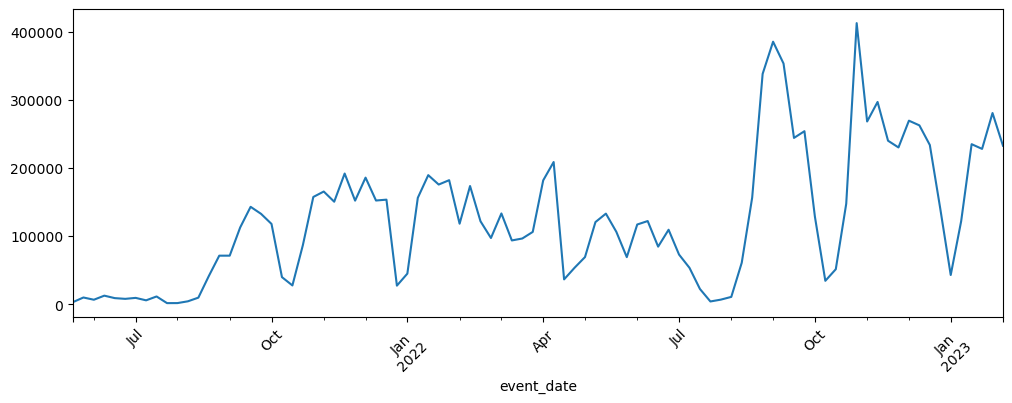

In [29]:
# Count total events per calendar week
weekly_events = events_clean.groupby(events_clean['event_date'].dt.to_period('W')).size()

# Drop the last week only if the dataset stops before that weekly period ends
last_week = weekly_events.index[-1]
if events_clean['event_date'].max() < last_week.end_time:
    weekly_events = weekly_events.iloc[:-1]

# Plot weekly event volume
weekly_events.plot(figsize=(12, 4))
plt.xticks(rotation=45)
plt.show()

In [30]:
# Quick sanity check of the engineered user-level feature table
print(user_features.shape)
print(user_features.head())

# Top 20 columns with missing values
print(user_features.isna().sum().sort_values(ascending=False).head(20))

# Share of users with events, transactions, and valid response-time info
print(user_features[['has_events', 'has_transactions', 'has_response_time']].mean())

(30929, 61)
   user_id   gender   canton          class_level  study class_id  n_events  \
0   387604  Unknown  Unknown              Unknown  False  Unknown    5087.0   
1   387605  Unknown  Unknown              Unknown  False  Unknown    3604.0   
2   387608  Unknown  Unknown              Unknown   True    9Q2M7    2359.0   
3   387613  Unknown  Unknown              Unknown  False  Unknown     213.0   
4   387615     MALE       SG  Gymnasium - 3. Jahr  False  Unknown     535.0   

   n_active_days  n_active_weeks             first_event  ...  \
0          100.0            54.0 2021-05-22 05:12:11.416  ...   
1           54.0            33.0 2021-05-27 06:46:53.301  ...   
2           87.0            47.0 2021-09-05 08:29:42.198  ...   
3            5.0             4.0 2021-07-28 07:55:26.135  ...   
4           12.0             9.0 2021-08-28 13:14:30.684  ...   

  avg_response_time  median_response_time  n_challenges  has_events  \
0         53.863150               18.2290          

In [31]:
print(dropout_dataset.shape)
print(dropout_dataset['dropout'].value_counts())
print(dropout_dataset['dropout'].value_counts(normalize=True).round(3))
print(dropout_dataset.head())

(22470, 28)
dropout
1    14577
0     7893
Name: count, dtype: int64
dropout
1    0.649
0    0.351
Name: proportion, dtype: float64
   user_id  total_events_0_2  total_transactions_0_2  total_clicks_0_2  \
0   387604               2.0                     2.0               0.0   
1   387605              12.0                     5.0               7.0   
2   387608             101.0                    34.0              35.0   
3   387613              11.0                     2.0               3.0   
4   387615             348.0                    37.0              76.0   

   total_views_0_2  total_sessions_0_2  total_topics_event_0_2  \
0              2.0                 0.0                     0.0   
1              5.0                 2.0                     2.0   
2             66.0                 2.0                     1.0   
3              8.0                 1.0                     1.0   
4            272.0                 2.0                     1.0   

   total_topics_transaction

### Alternative definition of dropout :

In [32]:
def overlaps_summer(row):
        if pd.isna(row["gap_start"]) or pd.isna(row["gap_end"]):
            return False

        start = row["gap_start"]
        end = row["gap_end"]

        # iterate over years spanned by the gap
        for year in range(start.year, end.year + 1):
            july_start = pd.Timestamp(year=year, month=7, day=1)
            aug_end = pd.Timestamp(year=year, month=8, day=31)

            # overlap condition
            if not (end < july_start or start > aug_end):
                return True

        return False

def compute_dropout(events_week, users_features):

    df = events_week.merge(
        users_features[["user_id", "first_event"]],
        on="user_id",
        how="left"
    )
    # compute week start date
    df["week_start"] = df["first_event"] + pd.to_timedelta(df["relative_week"] * 7, unit="D")

    # 1. ensure ordering
    df = df.sort_values(["user_id", "relative_week"]).copy()

    # 2. gap between weeks
    df["week_diff"] = df.groupby("user_id")["relative_week"].diff()

    df["prev_week_start"] = df.groupby("user_id")["week_start"].shift(1)

    df["gap_start"] = df["prev_week_start"] + pd.Timedelta(days=7)
    df["gap_end"] = df["week_start"] - pd.Timedelta(days=7)

    df["overlaps_summer"] = df.apply(overlaps_summer, axis=1)

    # 3. condition de dropout
    df["is_dropout_point"] = (
        (df["week_diff"] > 4) &            # >= 4 weeks gap
        (~df["overlaps_summer"])           # NOT during summer
    )
    # shift dropout to previous week (within each user)
    df["is_dropout_point"] = df.groupby("user_id")["is_dropout_point"].shift(-1).fillna(False)

    today = pd.Timestamp.today()

    # identify last week per user
    df["is_last_week"] = df.groupby("user_id")["relative_week"].transform("max") == df["relative_week"]

    # compute how old the last week is
    df["weeks_since"] = (today - df["week_start"]).dt.days / 7

    # apply rule only on last week
    df.loc[df["is_last_week"], "is_dropout_point"] = df.loc[df["is_last_week"], "weeks_since"] > 4

    # 3. récupérer le premier dropout par user
    dropout_df = df[df["is_dropout_point"]].copy()
    dropout_df["dropout_week"] = dropout_df["relative_week"].shift(1)

    first_dropout = (
        dropout_df.groupby("user_id")
        .first()[["dropout_week"]]
        .reset_index()
    )
    first_dropout["dropout_indicator"] = 1

    # 7. users sans dropout → dernière semaine
    last_weeks = (
        df.groupby("user_id")["relative_week"]
        .max()
        .reset_index()
        .rename(columns={"relative_week": "dropout_week"})
    )
    last_weeks["dropout_indicator"] = 0

    # 8. merge final
    result = last_weeks.merge(first_dropout, on="user_id", how="left", suffixes=("", "_drop"))

    # si dropout existe → overwrite
    result["dropout_indicator"] = result["dropout_indicator_drop"].fillna(result["dropout_indicator"])
    result["dropout_week"] = result["dropout_week_drop"].fillna(result["dropout_week"])

    # cleanup
    result = result[["user_id", "dropout_indicator", "dropout_week"]]

    return result, df

In [33]:
df_dropout, week_dropout_df = compute_dropout(user_week_features, user_features)

In [35]:
week_dropout_df = week_dropout_df.copy()

week_dropout_df["cum_events"] = week_dropout_df.groupby("user_id")["n_events"].cumsum()
week_dropout_df["cum_ratio"] = (
    week_dropout_df["cum_events"]
    / week_dropout_df.groupby("user_id")["n_events"].transform("sum").replace(0, np.nan)
)

week_dropout_df.loc[
    week_dropout_df["user_id"] == 387615,
    ["user_id", "relative_week", "n_events", "cum_events", "cum_ratio", "week_diff", "is_dropout_point", "week_start"]
]

,user_id,relative_week,n_events,cum_events,cum_ratio,week_diff,is_dropout_point,week_start
140,387615,-1,128.0,128.0,0.239252,<NA>,False,2021-08-21 13:14:30.684
141,387615,0,107.0,235.0,0.439252,1,False,2021-08-28 13:14:30.684
142,387615,1,112.0,347.0,0.648598,1,False,2021-09-04 13:14:30.684
143,387615,2,129.0,476.0,0.889720,1,False,2021-09-11 13:14:30.684
144,387615,4,16.0,492.0,0.919626,2,True,2021-09-25 13:14:30.684
145,387615,25,16.0,508.0,0.949533,21,False,2022-02-19 13:14:30.684
146,387615,55,23.0,531.0,0.992523,30,True,2022-09-17 13:14:30.684
147,387615,74,4.0,535.0,1.000000,19,True,2023-01-28 13:14:30.684


In [36]:
df_dropout.head(5)

,user_id,dropout_indicator,dropout_week
0,387604,1,70
1,387605,1,87
2,387608,1,74
3,387613,1,72
4,387615,1,7


## LSTM Model

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [38]:
def build_full_timeline(df):
    users = df["user_id"].unique()
    full_data = []

    for user in users:
        user_df = df[df["user_id"] == user]
        max_week = user_df["relative_week"].max()

        full_weeks = pd.DataFrame({
            "user_id": user,
            "relative_week": np.arange(0, max_week + 1)
        })

        merged = full_weeks.merge(
            user_df,
            on=["user_id", "relative_week"],
            how="left"
        )

        full_data.append(merged)

    return pd.concat(full_data, ignore_index=True)

df_full = build_full_timeline(user_week_features)

In [39]:
feature_cols = [
    "n_events", "n_active_days", "mean_hour",
    "n_click_events", "n_view_events", "n_sessions",
    "n_topics_event", "n_transactions",
    "correct_rate", "partial_rate", "mean_evaluation_score",
    "avg_response_time", "n_topics_transaction","n_documents",
    "activity_score"
]

df_full[feature_cols] = df_full[feature_cols].fillna(0)

In [40]:
def overlaps_summer_period(start, end):
    if pd.isna(start) or pd.isna(end):
        return False

    for year in range(start.year, end.year + 1):
        july_start = pd.Timestamp(year=year, month=7, day=1)
        aug_end = pd.Timestamp(year=year, month=8, day=31)

        if not (end < july_start or start > aug_end):
            return True

    return False


def compute_dropout_full_timeline(df, users_features, horizon=4):
    df = df.merge(
        users_features[["user_id", "first_event"]],
        on="user_id",
        how="left"
    )

    # compute week_start
    df["week_start"] = df["first_event"] + pd.to_timedelta(df["relative_week"] * 7, unit="D")

    df = df.sort_values(["user_id", "relative_week"]).copy()

    # activity indicator
    df["is_active"] = (df["n_events"] > 0).astype(int)

    labels = []

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values("relative_week")
        activity = user_df["is_active"].values
        weeks = user_df["week_start"].values
        n = len(user_df)

        user_labels = np.full(n, np.nan)

        for i in range(n):
            # need full horizon
            if i + horizon < n:
                future_activity = activity[i+1:i+1+horizon]

                if np.all(future_activity == 0):
                    gap_start = weeks[i] + np.timedelta64(7, 'D')
                    gap_end = weeks[i] + np.timedelta64(7*horizon, 'D')

                    if not overlaps_summer_period(pd.Timestamp(gap_start), pd.Timestamp(gap_end)):
                        user_labels[i] = 1
                    else:
                        user_labels[i] = 0
                else:
                    user_labels[i] = 0
            else:
                user_labels[i] = np.nan  # cannot determine

        labels.extend(user_labels)

    df["is_dropout_point"] = labels
    return df

df_full = compute_dropout_full_timeline(df_full, user_features)

In [41]:
# Step 1: get the starting week (relative_week = 0) for each user
start_dates = (
    week_dropout_df[week_dropout_df["relative_week"] == 0]
    [["user_id", "week_start"]]
    .rename(columns={"week_start": "start_date"})
)

# Step 2: merge with df_full
df_full = df_full.merge(start_dates, on="user_id", how="left")

# Step 3: reconstruct the actual date for each row
df_full["date"] = df_full["start_date"] + pd.to_timedelta(df_full["relative_week"] * 7, unit="D")

# Step 4: extract year and day of year
df_full["year"] = df_full["date"].dt.year
df_full["day"] = df_full["date"].dt.dayofyear

# Optional: drop helper columns if you don't need them
df_full = df_full.drop(columns=["start_date", "date"])

feature_cols.append("year")
feature_cols.append("day")

In [42]:
df_full.head(30)

,user_id,relative_week,n_events,n_active_days,mean_hour,n_click_events,n_view_events,n_sessions,n_topics_event,n_transactions,...,avg_response_time,n_documents,n_topics_transaction,activity_score,first_event,week_start,is_active,is_dropout_point,year,day
0,387604,0,2.0,2.0,9.000000,0.0,2.0,0.0,0.0,2.0,...,0.000000,1.0,0.0,6.0,2021-05-22 05:12:11.416,2021-05-22 05:12:11.416,1,0.0,2021,142
1,387604,1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-05-29 05:12:11.416,0,0.0,2021,149
2,387604,2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-06-05 05:12:11.416,0,0.0,2021,156
3,387604,3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-06-12 05:12:11.416,0,0.0,2021,163
4,387604,4,7.0,1.0,8.000000,4.0,3.0,1.0,1.0,0.0,...,0.000000,0.0,0.0,14.0,2021-05-22 05:12:11.416,2021-06-19 05:12:11.416,1,0.0,2021,170
5,387604,5,25.0,1.0,8.800000,12.0,13.0,2.0,2.0,9.0,...,601.644167,9.0,2.0,59.0,2021-05-22 05:12:11.416,2021-06-26 05:12:11.416,1,0.0,2021,177
6,387604,6,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-07-03 05:12:11.416,0,0.0,2021,184
7,387604,7,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-07-10 05:12:11.416,0,0.0,2021,191
8,387604,8,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-07-17 05:12:11.416,0,0.0,2021,198
9,387604,9,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-07-24 05:12:11.416,0,0.0,2021,205


In [43]:
users = df_full["user_id"].unique()

# First split: train+val vs test
train_val_users, test_users = train_test_split(
    users, test_size=0.2, random_state=42
)

# Second split: train vs validation
train_users, val_users = train_test_split(
    train_val_users, test_size=0.2, random_state=42
)

train_df = df_full[df_full["user_id"].isin(train_users)].copy()
val_df   = df_full[df_full["user_id"].isin(val_users)].copy()
test_df  = df_full[df_full["user_id"].isin(test_users)].copy()

In [44]:
scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [45]:
SEQUENCE_LENGTH = 12

def create_sequences(df):
    sequences = []
    labels = []

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values("relative_week")

        data = user_df[feature_cols].values
        target = user_df["is_dropout_point"].values

        for i in range(SEQUENCE_LENGTH, len(user_df)):
            if np.isnan(target[i]):
              continue
            X = data[i-SEQUENCE_LENGTH:i]
            y = float(target[i])

            sequences.append(X)
            labels.append(y)

    return np.array(sequences), np.array(labels)

X_train, y_train = create_sequences(train_df)
X_val, y_val     = create_sequences(val_df)
X_test, y_test   = create_sequences(test_df)

In [46]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train, y_train)
val_dataset = SequenceDataset(X_val, y_val)
test_dataset = SequenceDataset(X_test, y_test)



train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [47]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size=64, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = h_n[-1]
        out = self.fc(out)
        return out.squeeze(-1)

In [ ]:
from sklearn.metrics import f1_score
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(input_size=len(feature_cols)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
patience = 5  # early stopping patience

best_f1 = 0
best_model_weights = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

threshold = 0.5  

for epoch in range(EPOCHS):

    # ===== TRAINING =====
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch)

        preds = preds.reshape(-1).float()
        y_batch = y_batch.reshape(-1).float()

        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)

            preds = preds.reshape(-1)
            y_batch = y_batch.reshape(-1)

            loss = criterion(preds, y_batch.float())
            val_loss += loss.item()

            probs = torch.sigmoid(preds)
            preds_binary = (probs > threshold).float()

            all_preds.extend(preds_binary.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    # ===== EARLY STOPPING ON F1 =====
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print("✅ New best model!")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("⏹ Early stopping triggered")
        break

# Load best model at the end
model.load_state_dict(best_model_weights)

print(f"Best Validation F1: {best_f1:.4f}")

Epoch 1 | Train Loss: 975.8528 | Val Loss: 224.7380 | Val F1: 0.7971
✅ New best model!
Epoch 2 | Train Loss: 916.2567 | Val Loss: 219.6791 | Val F1: 0.7847
Epoch 3 | Train Loss: 897.1006 | Val Loss: 218.5439 | Val F1: 0.8059
✅ New best model!
Epoch 4 | Train Loss: 880.4757 | Val Loss: 213.5516 | Val F1: 0.8144
✅ New best model!
Epoch 5 | Train Loss: 864.0045 | Val Loss: 212.8278 | Val F1: 0.8090
Epoch 6 | Train Loss: 851.1858 | Val Loss: 215.3838 | Val F1: 0.8093
Epoch 7 | Train Loss: 841.2446 | Val Loss: 213.1290 | Val F1: 0.8143
Epoch 8 | Train Loss: 832.4326 | Val Loss: 216.6049 | Val F1: 0.8138
Epoch 9 | Train Loss: 819.8419 | Val Loss: 213.3634 | Val F1: 0.8143
⏹ Early stopping triggered
Best Validation F1: 0.8144


In [49]:
from sklearn.metrics import roc_auc_score

model.eval()
preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        preds.extend(outputs.cpu().numpy())
        targets.extend(y_batch.numpy())

roc = roc_auc_score(targets, preds)
print("ROC-AUC:", roc)

ROC-AUC: 0.8766518542365468


In [50]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import numpy as np

model.eval()
preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        probs = torch.sigmoid(outputs)

        preds.extend(probs.cpu().numpy())
        targets.extend(y_batch.numpy())

preds = np.array(preds)
targets = np.array(targets)

In [51]:
threshold = 0.5
pred_labels = (preds > threshold).astype(int)

print("F1:", f1_score(targets, pred_labels))
print("Precision:", precision_score(targets, pred_labels))
print("Recall:", recall_score(targets, pred_labels))

F1: 0.816288202151272
Precision: 0.749461143551358
Recall: 0.8961994470218848


In [52]:
best_f1 = 0
best_thresh = 0

for t in np.linspace(0.1, 0.9, 50):
    pred_labels = (preds > t).astype(int)
    f1 = f1_score(targets, pred_labels)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best F1:", best_f1)
print("Best threshold:", best_thresh)

Best F1: 0.8228107559614409
Best threshold: 0.4102040816326531


## Light GBM

In [53]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

In [54]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",  # important if imbalance
    random_state=42
)

model_lgb.fit(
    X_train_flat, y_train,
    eval_set=[(X_val_flat, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=True)]
)

[LightGBM] [Info] Number of positive: 67768, number of negative: 69095
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36855
[LightGBM] [Info] Number of data points in the train set: 136863, number of used features: 204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [55]:
from sklearn.metrics import roc_auc_score

preds = model_lgb.predict_proba(X_test_flat)[:, 1]

roc = roc_auc_score(y_test, preds)
print("LightGBM ROC-AUC:", roc)

LightGBM ROC-AUC: 0.8924967653806078


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [56]:
from sklearn.metrics import f1_score, precision_score, recall_score

threshold = 0.5
pred_labels = (preds > threshold).astype(int)

print("F1:", f1_score(y_test, pred_labels))
print("Precision:", precision_score(y_test, pred_labels))
print("Recall:", recall_score(y_test, pred_labels))

F1: 0.8309744030974403
Precision: 0.7680012723152161
Recall: 0.9051970570317259


In [57]:
import numpy as np

best_f1 = 0
best_thresh = 0

for t in np.linspace(0.1, 0.9, 50):
    pred_labels = (preds > t).astype(int)
    f1 = f1_score(y_test, pred_labels)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best F1:", best_f1)
print("Best threshold:", best_thresh)

Best F1: 0.8347046877289952
Best threshold: 0.44285714285714284


# EVALUTATION OF FEATURES

Evaluate which features are most important for the model.

We can do this by ablation, which consists in removing one feature at a time and evaluating the performance drop. 

This will give us an idea of which features are most important for the model.

In [58]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.6f}".format)


def get_best_metrics(y_true, y_score, thresholds=None):
    """
    Compute ROC-AUC and best F1 over a grid of thresholds.
    Returns:
        roc_auc, best_f1, best_threshold, precision_at_best, recall_at_best
    """
    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)

    roc = roc_auc_score(y_true, y_score)

    best_f1 = -1
    best_threshold = None
    best_precision = None
    best_recall = None

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)

        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_precision = precision
            best_recall = recall

    return roc, best_f1, best_threshold, best_precision, best_recall


def make_lgbm():
    """
    Same model configuration for every ablation.
    """
    return LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        class_weight="balanced",
        verbosity=-1
    )


def drop_original_features(X, feature_names, feature_cols, n_timesteps):
    """
    Drop original features across all timesteps.

    Example:
        feature_names = ["day"]
        removes:
            t0_day, t1_day, ..., t11_day
    """
    cols_to_drop = []

    for feature_name in feature_names:
        if feature_name not in feature_cols:
            raise ValueError(f"{feature_name} is not in feature_cols")

        feature_idx = feature_cols.index(feature_name)

        cols_to_drop.extend([
            t * len(feature_cols) + feature_idx
            for t in range(n_timesteps)
        ])

    X_reduced = np.delete(X, cols_to_drop, axis=1)
    return X_reduced, cols_to_drop


def build_flat_feature_names(feature_cols, n_timesteps):
    """
    Creates names like:
        t0_n_events, t0_year, t0_day, ..., t11_day
    """
    return [
        f"t{t}_{feature}"
        for t in range(n_timesteps)
        for feature in feature_cols
    ]


def extract_original_feature(flat_feature_name):
    """
    Converts:
        t0_day -> day
        t11_mean_hour -> mean_hour
        t10_n_view_events -> n_view_events
    """
    return "_".join(flat_feature_name.split("_")[1:])

run the baseline model

In [ ]:
baseline_preds = model_lgb.predict_proba(X_test_flat)[:, 1]

baseline_roc, baseline_f1, baseline_threshold, baseline_precision, baseline_recall = get_best_metrics(
    y_test,
    baseline_preds
)

baseline_results = {
    "experiment": "Baseline full model",
    "removed_features": "None",
    "n_removed_columns": 0,
    "roc_auc": baseline_roc,
    "f1": baseline_f1,
    "best_threshold": baseline_threshold,
    "precision": baseline_precision,
    "recall": baseline_recall,
    "roc_auc_drop": 0.0,
    "f1_drop": 0.0,
}

baseline_df = pd.DataFrame([baseline_results])

baseline_df

c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,experiment,removed_features,n_removed_columns,roc_auc,f1,best_threshold,precision,recall,roc_auc_drop,f1_drop
0,Baseline full model,None,0,0.892497,0.834825,0.440000,0.753671,0.935564,0.000000,0.000000


Ablation

In [63]:
from lightgbm import LGBMClassifier
main_ablation_configs = [
    {
        "experiment": "Remove year",
        "removed_features": ["year"],
    },
    {
        "experiment": "Remove day",
        "removed_features": ["day"],
    },
    {
        "experiment": "Remove year + day",
        "removed_features": ["year", "day"],
    },
]

main_ablation_results = []

for config in main_ablation_configs:
    experiment = config["experiment"]
    removed_features = config["removed_features"]

    print(f"Running: {experiment}")

    X_train_drop, cols_drop = drop_original_features(
        X_train_flat,
        removed_features,
        feature_cols,
        n_timesteps
    )

    X_test_drop, _ = drop_original_features(
        X_test_flat,
        removed_features,
        feature_cols,
        n_timesteps
    )

    model_drop = make_lgbm()
    model_drop.fit(X_train_drop, y_train)

    preds_drop = model_drop.predict_proba(X_test_drop)[:, 1]

    roc, f1, threshold, precision, recall = get_best_metrics(
        y_test,
        preds_drop
    )

    main_ablation_results.append({
        "experiment": experiment,
        "removed_features": ", ".join(removed_features),
        "n_removed_columns": len(cols_drop),
        "roc_auc": roc,
        "f1": f1,
        "best_threshold": threshold,
        "precision": precision,
        "recall": recall,
        "roc_auc_drop": baseline_roc - roc,
        "f1_drop": baseline_f1 - f1,
    })

main_ablation_df = pd.DataFrame(main_ablation_results)

main_results_df = pd.concat(
    [baseline_df, main_ablation_df],
    ignore_index=True
)

main_results_df

Running: Remove year


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Running: Remove day


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Running: Remove year + day


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,experiment,removed_features,n_removed_columns,roc_auc,f1,best_threshold,precision,recall,roc_auc_drop,f1_drop
0,Baseline full model,None,0,0.892497,0.834825,0.440000,0.753671,0.935564,0.000000,0.000000
1,Remove year,year,12,0.887058,0.828563,0.460000,0.732429,0.953747,0.005439,0.006262
2,Remove day,day,12,0.699341,0.684299,0.360000,0.533223,0.954824,0.193156,0.150526
3,Remove year + day,"year, day",24,0.598795,0.679656,0.390000,0.526172,0.959558,0.293701,0.155169


Summarz table

In [75]:
main_summary = main_results_df.copy()

main_summary = main_summary[
    [
        "experiment",
        "removed_features",
        "n_removed_columns",
        "roc_auc",
        "f1",
        "best_threshold",
        "precision",
        "recall",
        "roc_auc_drop",
        "f1_drop",
    ]
]

main_summary.style.format({
    "roc_auc": "{:.4f}",
    "f1": "{:.4f}",
    "best_threshold": "{:.2f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "roc_auc_drop": "{:.4f}",
    "f1_drop": "{:.4f}",
}).background_gradient(
    subset=["roc_auc_drop", "f1_drop"],
    cmap="Reds"
)

,experiment,removed_features,n_removed_columns,roc_auc,f1,best_threshold,precision,recall,roc_auc_drop,f1_drop
0,Baseline full model,None,0,0.8925,0.8348,0.44,0.7537,0.9356,0.0000,0.0000
1,Remove year,year,12,0.8871,0.8286,0.46,0.7324,0.9537,0.0054,0.0063
2,Remove day,day,12,0.6993,0.6843,0.36,0.5332,0.9548,0.1932,0.1505
3,Remove year + day,"year, day",24,0.5988,0.6797,0.39,0.5262,0.9596,0.2937,0.1552


Create a new baseline without year and day-of-year to see what are the most important features in the user-relative timeline.

In [65]:
base_removed_features = ["year", "day"]

X_train_no_time, removed_time_cols = drop_original_features(
    X_train_flat,
    base_removed_features,
    feature_cols,
    n_timesteps
)

X_test_no_time, _ = drop_original_features(
    X_test_flat,
    base_removed_features,
    feature_cols,
    n_timesteps
)

feature_cols_no_time = [
    feature for feature in feature_cols
    if feature not in base_removed_features
]

model_no_time = make_lgbm()
model_no_time.fit(X_train_no_time, y_train)

preds_no_time = model_no_time.predict_proba(X_test_no_time)[:, 1]

roc_no_time, f1_no_time, threshold_no_time, precision_no_time, recall_no_time = get_best_metrics(
    y_test,
    preds_no_time
)

no_time_baseline_df = pd.DataFrame([{
    "experiment": "Baseline without year + day",
    "removed_features": "year, day",
    "n_removed_columns": len(removed_time_cols),
    "roc_auc": roc_no_time,
    "f1": f1_no_time,
    "best_threshold": threshold_no_time,
    "precision": precision_no_time,
    "recall": recall_no_time,
}])

print("X_train_no_time:", X_train_no_time.shape)
print("X_test_no_time:", X_test_no_time.shape)
print("Remaining original features:", feature_cols_no_time)

no_time_baseline_df

c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


X_train_no_time: (136863, 180)
X_test_no_time: (43511, 180)
Remaining original features: ['n_events', 'n_active_days', 'mean_hour', 'n_click_events', 'n_view_events', 'n_sessions', 'n_topics_event', 'n_transactions', 'correct_rate', 'partial_rate', 'mean_evaluation_score', 'avg_response_time', 'n_topics_transaction', 'n_documents', 'activity_score']


,experiment,removed_features,n_removed_columns,roc_auc,f1,best_threshold,precision,recall
0,Baseline without year + day,"year, day",24,0.598795,0.679656,0.390000,0.526172,0.959558


Ablations

In [66]:
def drop_original_feature_from_reduced(X, feature_name, reduced_feature_cols, n_timesteps):
    """
    Drop one original feature across all timesteps from a reduced matrix.

    Here the reduced matrix has 15 features per timestep instead of 17,
    because year and day have already been removed.
    """
    if feature_name not in reduced_feature_cols:
        raise ValueError(f"{feature_name} is not in reduced_feature_cols")

    feature_idx = reduced_feature_cols.index(feature_name)

    cols_to_drop = [
        t * len(reduced_feature_cols) + feature_idx
        for t in range(n_timesteps)
    ]

    X_reduced = np.delete(X, cols_to_drop, axis=1)
    return X_reduced, cols_to_drop


remaining_ablation_results = []

for feature in feature_cols_no_time:
    print("Testing without:", feature)

    X_train_drop, cols_drop = drop_original_feature_from_reduced(
        X_train_no_time,
        feature,
        feature_cols_no_time,
        n_timesteps
    )

    X_test_drop, _ = drop_original_feature_from_reduced(
        X_test_no_time,
        feature,
        feature_cols_no_time,
        n_timesteps
    )

    model_drop = make_lgbm()
    model_drop.fit(X_train_drop, y_train)

    preds_drop = model_drop.predict_proba(X_test_drop)[:, 1]

    roc, f1, threshold, precision, recall = get_best_metrics(
        y_test,
        preds_drop
    )

    remaining_ablation_results.append({
        "removed_feature": feature,
        "roc_auc_without": roc,
        "f1_without": f1,
        "best_threshold": threshold,
        "precision": precision,
        "recall": recall,
        "roc_auc_drop_vs_no_time": roc_no_time - roc,
        "f1_drop_vs_no_time": f1_no_time - f1,
    })

remaining_ablation_df = (
    pd.DataFrame(remaining_ablation_results)
    .sort_values("f1_drop_vs_no_time", ascending=False)
    .reset_index(drop=True)
)

remaining_ablation_df

Testing without: n_events


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_active_days


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: mean_hour


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_click_events


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_view_events


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_sessions


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_topics_event


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_transactions


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: correct_rate


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: partial_rate


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: mean_evaluation_score


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: avg_response_time


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_topics_transaction


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: n_documents


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing without: activity_score


c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,removed_feature,roc_auc_without,f1_without,best_threshold,precision,recall,roc_auc_drop_vs_no_time,f1_drop_vs_no_time
0,mean_hour,0.590578,0.677867,0.370000,0.522082,0.966165,0.008218,0.001789
1,n_active_days,0.597922,0.678288,0.410000,0.528847,0.945452,0.000874,0.001368
2,avg_response_time,0.598741,0.678661,0.410000,0.528672,0.947467,0.000055,0.000995
3,partial_rate,0.598225,0.678749,0.390000,0.525748,0.957355,0.000570,0.000907
4,mean_evaluation_score,0.598181,0.678844,0.380000,0.524139,0.963119,0.000615,0.000812
5,n_topics_transaction,0.598991,0.678863,0.370000,0.522811,0.967712,-0.000196,0.000793
6,n_click_events,0.598100,0.678893,0.390000,0.525596,0.958433,0.000696,0.000763
7,n_documents,0.597451,0.678915,0.390000,0.524837,0.961057,0.001344,0.000741
8,n_sessions,0.600434,0.679027,0.390000,0.525714,0.958574,-0.001639,0.000629
9,n_view_events,0.599183,0.679127,0.400000,0.527355,0.953559,-0.000388,0.000529


Tableau final

In [76]:
remaining_ablation_pretty = remaining_ablation_df.copy()
remaining_ablation_pretty.insert(0, "rank", np.arange(1, len(remaining_ablation_pretty) + 1))

remaining_ablation_pretty.style.format({
    "roc_auc_without": "{:.4f}",
    "f1_without": "{:.4f}",
    "best_threshold": "{:.2f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "roc_auc_drop_vs_no_time": "{:.4f}",
    "f1_drop_vs_no_time": "{:.4f}",
}).background_gradient(
    subset=["roc_auc_drop_vs_no_time", "f1_drop_vs_no_time"],
    cmap="Reds"
)

,rank,removed_feature,roc_auc_without,f1_without,best_threshold,precision,recall,roc_auc_drop_vs_no_time,f1_drop_vs_no_time
0,1,mean_hour,0.5906,0.6779,0.37,0.5221,0.9662,0.0082,0.0018
1,2,n_active_days,0.5979,0.6783,0.41,0.5288,0.9455,0.0009,0.0014
2,3,avg_response_time,0.5987,0.6787,0.41,0.5287,0.9475,0.0001,0.0010
3,4,partial_rate,0.5982,0.6787,0.39,0.5257,0.9574,0.0006,0.0009
4,5,mean_evaluation_score,0.5982,0.6788,0.38,0.5241,0.9631,0.0006,0.0008
5,6,n_topics_transaction,0.5990,0.6789,0.37,0.5228,0.9677,-0.0002,0.0008
6,7,n_click_events,0.5981,0.6789,0.39,0.5256,0.9584,0.0007,0.0008
7,8,n_documents,0.5975,0.6789,0.39,0.5248,0.9611,0.0013,0.0007
8,9,n_sessions,0.6004,0.6790,0.39,0.5257,0.9586,-0.0016,0.0006
9,10,n_view_events,0.5992,0.6791,0.40,0.5274,0.9536,-0.0004,0.0005


Try permutation importance as well to confirm the results of the ablation study.

In [68]:
# Use a subset to keep it fast.
# Increase to 20000 or full X_test_flat if you want more stable values.

from sklearn.inspection import permutation_importance


n_perm_samples = min(10000, X_test_flat.shape[0])

X_perm = X_test_flat[:n_perm_samples]
y_perm = y_test[:n_perm_samples]

perm_result_auc = permutation_importance(
    model_lgb,
    X_perm,
    y_perm,
    scoring="roc_auc",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

perm_flat_df = pd.DataFrame({
    "flat_feature": flat_feature_names,
    "importance_mean": perm_result_auc.importances_mean,
    "importance_std": perm_result_auc.importances_std,
})

perm_flat_df["original_feature"] = perm_flat_df["flat_feature"].apply(extract_original_feature)

perm_flat_df = (
    perm_flat_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

perm_flat_df.head(30)

c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,flat_feature,importance_mean,importance_std,original_feature
0,t0_day,0.142474,0.001431,day
1,t11_day,0.046367,0.002641,day
2,t10_day,0.028375,0.001395,day
3,t0_year,0.018043,0.000816,year
4,t2_day,0.009075,0.000878,day
5,t1_day,0.008057,0.000777,day
6,t11_year,0.005753,0.000210,year
7,t7_day,0.002794,0.000475,day
8,t11_mean_hour,0.002637,0.000594,mean_hour
9,t10_n_view_events,0.001884,0.000491,n_view_events


Aggregated permutation importance by original feature

In [69]:
perm_by_feature = (
    perm_flat_df
    .groupby("original_feature")
    .agg(
        total_importance=("importance_mean", "sum"),
        mean_importance=("importance_mean", "mean"),
        max_importance=("importance_mean", "max"),
        std_mean=("importance_std", "mean"),
    )
    .sort_values("total_importance", ascending=False)
    .reset_index()
)

perm_by_feature.insert(0, "rank", np.arange(1, len(perm_by_feature) + 1))

perm_by_feature.style.format({
    "total_importance": "{:.6f}",
    "mean_importance": "{:.6f}",
    "max_importance": "{:.6f}",
    "std_mean": "{:.6f}",
}).background_gradient(
    subset=["total_importance"],
    cmap="Blues"
)

,rank,original_feature,total_importance,mean_importance,max_importance,std_mean
0,1,day,0.239970,0.019997,0.142474,0.000696
1,2,year,0.023842,0.001987,0.018043,0.000110
2,3,mean_hour,0.005575,0.000465,0.002637,0.000228
3,4,n_view_events,0.005049,0.000421,0.001884,0.000164
4,5,activity_score,0.002337,0.000195,0.000743,0.000107
5,6,n_events,0.002014,0.000168,0.000535,0.000083
6,7,n_click_events,0.001895,0.000158,0.000317,0.000062
7,8,n_documents,0.001304,0.000109,0.000380,0.000116
8,9,avg_response_time,0.001198,0.000100,0.000395,0.000062
9,10,n_topics_transaction,0.001162,0.000097,0.000346,0.000043


MAXI TABLEAU FINAAAL

In [77]:
final_summary_rows = []

# Main experiments
for _, row in main_results_df.iterrows():
    final_summary_rows.append({
        "analysis_type": "Main ablation",
        "experiment": row["experiment"],
        "removed_features": row["removed_features"],
        "reference": "Full baseline",
        "roc_auc": row["roc_auc"],
        "f1": row["f1"],
        "roc_auc_drop": row["roc_auc_drop"],
        "f1_drop": row["f1_drop"],
    })

# Baseline without time
final_summary_rows.append({
    "analysis_type": "No-time baseline",
    "experiment": "Baseline without year + day",
    "removed_features": "year, day",
    "reference": "Full baseline",
    "roc_auc": roc_no_time,
    "f1": f1_no_time,
    "roc_auc_drop": baseline_roc - roc_no_time,
    "f1_drop": baseline_f1 - f1_no_time,
})

# Top remaining features
for _, row in remaining_ablation_df.head(5).iterrows():
    final_summary_rows.append({
        "analysis_type": "Remaining-feature ablation",
        "experiment": f"Remove {row['removed_feature']} after removing year + day",
        "removed_features": row["removed_feature"],
        "reference": "Baseline without year + day",
        "roc_auc": row["roc_auc_without"],
        "f1": row["f1_without"],
        "roc_auc_drop": row["roc_auc_drop_vs_no_time"],
        "f1_drop": row["f1_drop_vs_no_time"],
    })

# Top permutation features
for _, row in perm_by_feature.head(5).iterrows():
    final_summary_rows.append({
        "analysis_type": "Permutation importance",
        "experiment": f"Permutation importance: {row['original_feature']}",
        "removed_features": row["original_feature"],
        "reference": "Full trained model",
        "roc_auc": np.nan,
        "f1": np.nan,
        "roc_auc_drop": row["total_importance"],
        "f1_drop": np.nan,
    })

final_summary_df = pd.DataFrame(final_summary_rows)

final_summary_df.style.format({
    "roc_auc": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc_drop": "{:.4f}",
    "f1_drop": "{:.4f}",
}, na_rep="-").background_gradient(
    subset=["roc_auc_drop"],
    cmap="Reds"
)

,analysis_type,experiment,removed_features,reference,roc_auc,f1,roc_auc_drop,f1_drop
0,Main ablation,Baseline full model,None,Full baseline,0.8925,0.8348,0.0000,0.0000
1,Main ablation,Remove year,year,Full baseline,0.8871,0.8286,0.0054,0.0063
2,Main ablation,Remove day,day,Full baseline,0.6993,0.6843,0.1932,0.1505
3,Main ablation,Remove year + day,"year, day",Full baseline,0.5988,0.6797,0.2937,0.1552
4,No-time baseline,Baseline without year + day,"year, day",Full baseline,0.5988,0.6797,0.2937,0.1552
5,Remaining-feature ablation,Remove mean_hour after removing year + day,mean_hour,Baseline without year + day,0.5906,0.6779,0.0082,0.0018
6,Remaining-feature ablation,Remove n_active_days after removing year + day,n_active_days,Baseline without year + day,0.5979,0.6783,0.0009,0.0014
7,Remaining-feature ablation,Remove avg_response_time after removing year + day,avg_response_time,Baseline without year + day,0.5987,0.6787,0.0001,0.0010
8,Remaining-feature ablation,Remove partial_rate after removing year + day,partial_rate,Baseline without year + day,0.5982,0.6787,0.0006,0.0009
9,Remaining-feature ablation,Remove mean_evaluation_score after removing year + day,mean_evaluation_score,Baseline without year + day,0.5982,0.6788,0.0006,0.0008


In [78]:
day_row = main_results_df[main_results_df["removed_features"] == "day"].iloc[0]
year_row = main_results_df[main_results_df["removed_features"] == "year"].iloc[0]
year_day_row = main_results_df[main_results_df["removed_features"] == "year, day"].iloc[0]

top_perm = perm_by_feature.iloc[0]
top_remaining = remaining_ablation_df.iloc[0]

conclusion = f"""
Baseline full model:
- ROC-AUC = {baseline_roc:.4f}
- F1 = {baseline_f1:.4f}

Removing year:
- ROC-AUC = {year_row["roc_auc"]:.4f}
- F1 = {year_row["f1"]:.4f}
- ROC-AUC drop = {year_row["roc_auc_drop"]:.4f}
- F1 drop = {year_row["f1_drop"]:.4f}

Removing day:
- ROC-AUC = {day_row["roc_auc"]:.4f}
- F1 = {day_row["f1"]:.4f}
- ROC-AUC drop = {day_row["roc_auc_drop"]:.4f}
- F1 drop = {day_row["f1_drop"]:.4f}

Removing year + day:
- ROC-AUC = {year_day_row["roc_auc"]:.4f}
- F1 = {year_day_row["f1"]:.4f}
- ROC-AUC drop = {year_day_row["roc_auc_drop"]:.4f}
- F1 drop = {year_day_row["f1_drop"]:.4f}

Permutation importance
- Most important feature = {top_perm["original_feature"]}
- Total permutation importance = {top_perm["total_importance"]:.6f}

After removing year and day, the most useful remaining feature is:
- {top_remaining["removed_feature"]}
- F1 drop vs no-time baseline = {top_remaining["f1_drop_vs_no_time"]:.6f}
"""

print(conclusion)


Baseline full model:
- ROC-AUC = 0.8925
- F1 = 0.8348

Removing year:
- ROC-AUC = 0.8871
- F1 = 0.8286
- ROC-AUC drop = 0.0054
- F1 drop = 0.0063

Removing day:
- ROC-AUC = 0.6993
- F1 = 0.6843
- ROC-AUC drop = 0.1932
- F1 drop = 0.1505

Removing year + day:
- ROC-AUC = 0.5988
- F1 = 0.6797
- ROC-AUC drop = 0.2937
- F1 drop = 0.1552

Permutation importance
- Most important feature = day
- Total permutation importance = 0.239970

After removing year and day, the most useful remaining feature is:
- mean_hour
- F1 drop vs no-time baseline = 0.001789



# Early drop prediction

## Setup

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

import lightgbm as lgb

DATA_DIR    = Path("data")
OUT_DATASET = DATA_DIR / "stage1.csv.gz"
OUT_PREDS   = DATA_DIR / "stage1_preds.csv.gz"

if not OUT_DATASET.exists():
    raise FileNotFoundError(
        f"{OUT_DATASET} not found. Run `stage_1_data.ipynb` first to build it."
    )

## Load the dataset

In [4]:
df = pd.read_csv(OUT_DATASET)
feature_cols = [c for c in df.columns if c not in ("user_id", "came_back")]
print(f"rows: {len(df):,}  features: {len(feature_cols)}")
print(f"came_back rate: {df['came_back'].mean():.3f}")
df.head()

rows: 22,466  features: 88
came_back rate: 0.608


,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,...,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,...,0,0,0,0,1,0,0,0,0,1
1,387605,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,...,0,0,0,0,1,0,0,0,0,1
2,387608,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,...,0,0,0,0,1,0,0,0,0,1
3,387613,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,...,0,0,0,0,1,0,0,0,0,1
4,387615,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,...,0,0,0,0,0,0,0,0,0,1


## Train / val / test split

Stratified by label since this is per-user classification.

In [5]:
train_val_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["came_back"]
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, random_state=42, stratify=train_val_df["came_back"]
)
print("train:", train_df.shape, "  val:", val_df.shape, "  test:", test_df.shape)

train: (14377, 90)   val: (3595, 90)   test: (4494, 90)


## LightGBM

In [6]:
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    n_jobs=1,
    verbose=-1,
)

model_lgb.fit(
    train_df[feature_cols], train_df["came_back"],
    eval_set=[(val_df[feature_cols], val_df["came_back"])],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=True)],
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[383]	valid_0's auc: 0.777773	valid_0's binary_logloss: 0.562595


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Tune the decision threshold on the validation set, then report on the test set

In [7]:
val_p = model_lgb.predict_proba(val_df[feature_cols])[:, 1]
test_p = model_lgb.predict_proba(test_df[feature_cols])[:, 1]

best_f1, best_t = 0.0, 0.5
for t in np.linspace(0.1, 0.9, 50):
    f1 = f1_score(val_df["came_back"], (val_p > t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Val best threshold: {best_t:.3f}  (val F1 = {best_f1:.4f})")

test_yhat = (test_p > best_t).astype(int)
print(f"\nTest ROC-AUC:   {roc_auc_score(test_df['came_back'], test_p):.4f}")
print(f"Test F1:        {f1_score(test_df['came_back'], test_yhat):.4f}")
print(f"Test Precision: {precision_score(test_df['came_back'], test_yhat):.4f}")
print(f"Test Recall:    {recall_score(test_df['came_back'], test_yhat):.4f}")

print("\nConfusion matrix (rows = true, cols = pred):")
print(confusion_matrix(test_df["came_back"], test_yhat))

print("\nClassification report:")
print(classification_report(
    test_df["came_back"], test_yhat,
    target_names=["left", "came_back"],
))

Val best threshold: 0.361  (val F1 = 0.7886)

Test ROC-AUC:   0.7733
Test F1:        0.7876
Test Precision: 0.7138
Test Recall:    0.8784

Confusion matrix (rows = true, cols = pred):
[[ 801  962]
 [ 332 2399]]

Classification report:
              precision    recall  f1-score   support

        left       0.71      0.45      0.55      1763
   came_back       0.71      0.88      0.79      2731

    accuracy                           0.71      4494
   macro avg       0.71      0.67      0.67      4494
weighted avg       0.71      0.71      0.70      4494



### Feature importances (LightGBM gain)

Top 15 by gain:
class_year                        7850.0
n_active_days_0_2                 6214.0
mean_hour_0_2                     6008.0
review_rate_0_2                   4001.0
canton_SG                         3762.0
avg_response_time_0_2             3170.0
time_between_sessions_mean_0_2    2935.0
std_hour_0_2                      2898.0
session_duration_mean_0_2         2862.0
mean_evaluation_score_0_2         2591.0
partial_rate_0_2                  2513.0
std_response_time_0_2             2464.0
retry_ratio_0_2                   2410.0
n_view_events_0_2                 2184.0
study                             2033.0


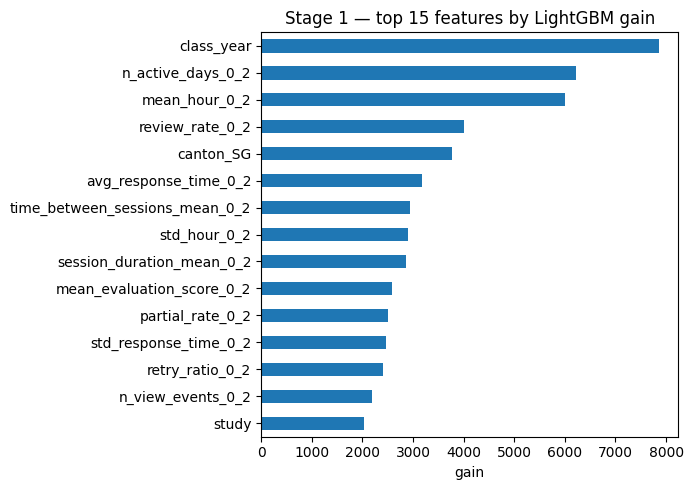

In [8]:
imp = pd.Series(
    model_lgb.booster_.feature_importance(importance_type="gain"),
    index=feature_cols,
).sort_values(ascending=False)

print("Top 15 by gain:")
print(imp.head(15).round(0).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
imp.head(15).iloc[::-1].plot.barh(ax=ax)
ax.set_title("Stage 1 \u2014 top 15 features by LightGBM gain")
ax.set_xlabel("gain")
plt.tight_layout()
plt.show()

## Feature-set ablation

Stage 1 extends `preprocess.ipynb`'s baseline with 8 additional behavioural features 

**Cumulative ablation** — start from baseline, add one group at a time. Shows where the AUC lift accrues.

In [9]:
GROUP_BASELINE = [
    "total_events_0_2", "n_active_days_0_2", "mean_hour_0_2",
    "n_click_events_0_2", "n_view_events_0_2",
    "n_sessions_0_2", "n_topics_event_0_2",
    "total_transactions_0_2",
    "correct_rate_0_2", "partial_rate_0_2", "mean_evaluation_score_0_2",
    "avg_response_time_0_2", "n_topics_transaction_0_2", "n_documents_0_2",
]
GROUP_ADDITIONAL = [
    # Std twins — Swamy, Marras, Käser L@S 2022
    "std_hour_0_2", "std_evaluation_score_0_2", "std_response_time_0_2",
    # Session shape — Chen & Cui 2020
    "session_duration_mean_0_2", "session_duration_std_0_2",
    "time_between_sessions_mean_0_2",
    # Wheel-spinning / engagement ratios — Beck & Gong 2013
    "retry_ratio_0_2", "review_rate_0_2",
]

_NAMED = set(GROUP_BASELINE) | set(GROUP_ADDITIONAL)
GROUP_DEMOGRAPHICS = [c for c in feature_cols if c not in _NAMED]

print(f"  baseline:     {len(GROUP_BASELINE):3d}")
print(f"  additional:   {len(GROUP_ADDITIONAL):3d}")
print(f"  demographics: {len(GROUP_DEMOGRAPHICS):3d}")
total = len(GROUP_BASELINE) + len(GROUP_ADDITIONAL) + len(GROUP_DEMOGRAPHICS)
print(f"  TOTAL:        {total:3d}  (== {len(feature_cols)} feature_cols)")

  baseline:      14
  additional:     8
  demographics:  66
  TOTAL:         88  (== 88 feature_cols)


In [10]:
def run_lgbm(cols, label="run"):
    """Train one LightGBM on `cols`, val-tune the F1 threshold, return test metrics."""
    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31,
        class_weight="balanced", random_state=42, n_jobs=1, verbose=-1,
    )
    m.fit(
        train_df[cols], train_df["came_back"],
        eval_set=[(val_df[cols], val_df["came_back"])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    val_pp = m.predict_proba(val_df[cols])[:, 1]
    test_pp = m.predict_proba(test_df[cols])[:, 1]

    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.1, 0.9, 50):
        f1 = f1_score(val_df["came_back"], (val_pp > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    test_yhat = (test_pp > best_t).astype(int)

    return {
        "set": label,
        "n_features": len(cols),
        "test_roc_auc": roc_auc_score(test_df["came_back"], test_pp),
        "test_f1": f1_score(test_df["came_back"], test_yhat),
        "test_precision": precision_score(test_df["came_back"], test_yhat),
        "test_recall": recall_score(test_df["came_back"], test_yhat),
    }

In [11]:
def run_lr(cols, label="run"):
    """Train Logistic Regression on `cols` (StandardScaler-fit per ablation row), val-tune the F1 threshold, return test metrics."""
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[cols])
    X_val   = scaler.transform(val_df[cols])
    X_test  = scaler.transform(test_df[cols])

    lr = LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42,
    )
    lr.fit(X_train, train_df["came_back"])
    val_pp  = lr.predict_proba(X_val)[:, 1]
    test_pp = lr.predict_proba(X_test)[:, 1]

    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.1, 0.9, 50):
        f1 = f1_score(val_df["came_back"], (val_pp > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    test_yhat = (test_pp > best_t).astype(int)

    return {
        "set": label,
        "n_features": len(cols),
        "test_roc_auc":   roc_auc_score(test_df["came_back"], test_pp),
        "test_f1":        f1_score(test_df["came_back"], test_yhat),
        "test_precision": precision_score(test_df["came_back"], test_yhat),
        "test_recall":    recall_score(test_df["came_back"], test_yhat),
    }

### Cumulative ablation

Each row adds the named group to the previous row's feature set.

In [12]:
cumulative_specs = [("Baseline", list(GROUP_BASELINE))]
running = list(GROUP_BASELINE)
for label, group in [
    ("+ Additional", GROUP_ADDITIONAL),
    ("+ Demographics", GROUP_DEMOGRAPHICS),
]:
    running = running + group
    cumulative_specs.append((label, list(running)))

cum_results = []
for label, cols in cumulative_specs:
    print(f"running '{label}' ({len(cols)} feats)...")
    cum_results.append(run_lgbm(cols, label=label))

cum_df = pd.DataFrame(cum_results)
cum_df.style.format({
    "test_roc_auc": "{:.4f}", "test_f1": "{:.4f}",
    "test_precision": "{:.4f}", "test_recall": "{:.4f}",
})

running 'Baseline' (14 feats)...
running '+ Additional' (22 feats)...
running '+ Demographics' (88 feats)...


,set,n_features,test_roc_auc,test_f1,test_precision,test_recall
0,Baseline,14,0.6359,0.7545,0.6107,0.9868
1,+ Additional,22,0.6485,0.7568,0.6090,0.9993
2,+ Demographics,88,0.7733,0.7876,0.7138,0.8784


### Cumulative ablation — Logistic Regression


In [13]:
cum_lr_results = []
for label, cols in cumulative_specs:
    print(f"running '{label}' (LR, {len(cols)} feats)...")
    cum_lr_results.append(run_lr(cols, label=label))

cum_lr_df = pd.DataFrame(cum_lr_results)
cum_lr_df.style.format({
    "test_roc_auc": "{:.4f}", "test_f1": "{:.4f}",
    "test_precision": "{:.4f}", "test_recall": "{:.4f}",
})

running 'Baseline' (LR, 14 feats)...
running '+ Additional' (LR, 22 feats)...
running '+ Demographics' (LR, 88 feats)...


,set,n_features,test_roc_auc,test_f1,test_precision,test_recall
0,Baseline,14,0.6200,0.7560,0.6077,1.0000
1,+ Additional,22,0.6243,0.7560,0.6077,1.0000
2,+ Demographics,88,0.7087,0.7624,0.6477,0.9264
